In [1]:
#C:/Users/alim10/mini/BiSe_232deg_38p7nm_static_6.h5

In [2]:
#Importing libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import h5py

plt.rcParams.update({"figure.autolayout": True, "image.cmap": "inferno"})

In [3]:
fp = 'BiSe_232deg_38p7nm_static_6.h5'

In [4]:
def structure(name, obj):
    print(name)
with h5py.File(fp, 'r') as f:
    f.visititems(structure)

scan0
scan0/image
scan0/lastimage
scan0/positions
scan0/temperatures


In [11]:
with h5py.File(fp, 'r') as f:
    # Read the data into a variable called 'data'
    data = f['scan0/image'][:]
    print(data.shape) # This will print: (20, 1, 576, 864)

(20, 1, 576, 864)


In [12]:
with h5py.File(fp, "r") as f:
    f.visititems(
        lambda n, o: print(f"{n}: {o.shape}") if hasattr(o, "shape") else None)

scan0/image: (20, 1, 576, 864)
scan0/lastimage: (576, 864)
scan0/positions: (1,)
scan0/temperatures: (1, 20)


In [13]:
with h5py.File(fp, "r") as f:
    data = f["scan0/image"][:]  # 2D/3D Intensity matrix
    attrs = dict(f["scan0/image"].attrs)  # Metadata & axis limits
    temps = f["scan0/temperatures"][:]  # Measured temperatures

print(f"Data Shape: {data.shape} | Attributes: {list(attrs.keys())}")

Data Shape: (20, 1, 576, 864) | Attributes: ['DIMENSION_FACTORS', 'DIMENSION_LABELS', 'DIMENSION_LIST', 'DIMENSION_OFFSETS', 'DIMENSION_UNITS', 'SPECSVERSION']


In [14]:
for k, v in attrs.items():
    print(f"{k}: {v}")

DIMENSION_FACTORS: [ 1.0000000e+00 -1.0000000e+02  8.2777377e-02  6.8005575e-03]
DIMENSION_LABELS: [b'repetition' b'delay' b'angle' b'energy']
DIMENSION_LIST: [array([], dtype=object) array([<HDF5 object reference>], dtype=object)
 array([], dtype=object) array([], dtype=object)]
DIMENSION_OFFSETS: [ 0.00000000e+00  1.40500000e+05  2.45021036e+01 -2.50621592e+01]
DIMENSION_UNITS: [b'' b'fs' b'deg' b'eV']
SPECSVERSION: 1


with h5py.File(fp, 'r') as f:
    for path in ['scan0/image', 'scan0/lastimage', 'scan0/positions', 'scan0/temperatures']:
        data = f[path][()] # Load data into memory
        
        print(f"--- Path: {path} ---")
        print(f"Shape: {data.shape}")
        print(f"Type:  {data.dtype}")
        print(f"Size:  {data.size}")     
        # If it's a small array (like positions or temps), print it all
        # If it's a big image, just print the max/min/mean
        if data.size < 50:
            print(f"Value: {data}")
        else:
            print(f"Stats: Min={data.min()}, Max={data.max()}, Mean={data.mean():.2f}")
        print("-" * 30)

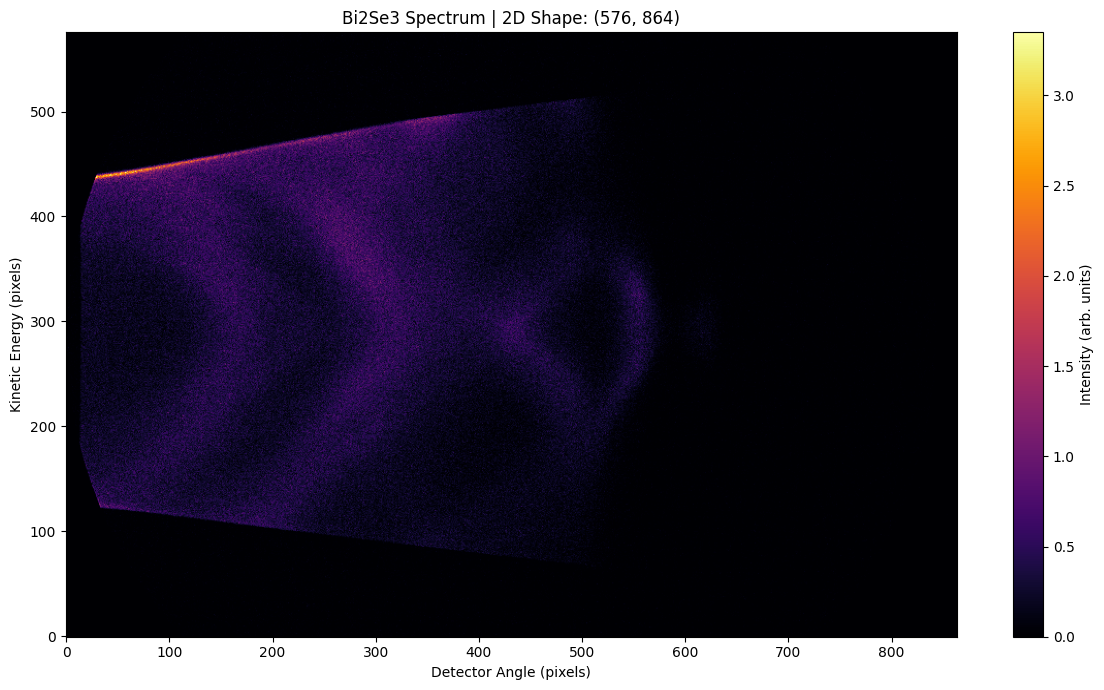

In [15]:
# Flatten any extra outer dimensions and average down strictly to 2D
img2d = data.reshape(-1, 576, 864).mean(axis=0) 
# or, img_all = data.squeeze().mean(axis=0)  # Shape: (576, 864)
plt.figure(figsize=(12, 7))
plt.imshow(img2d, aspect="auto", origin="lower")
plt.colorbar(label="Intensity (arb. units)")
plt.xlabel("Detector Angle (pixels)")
plt.ylabel("Kinetic Energy (pixels)")
plt.title(f"Bi2Se3 Spectrum | 2D Shape: {img2d.shape}")
plt.show()

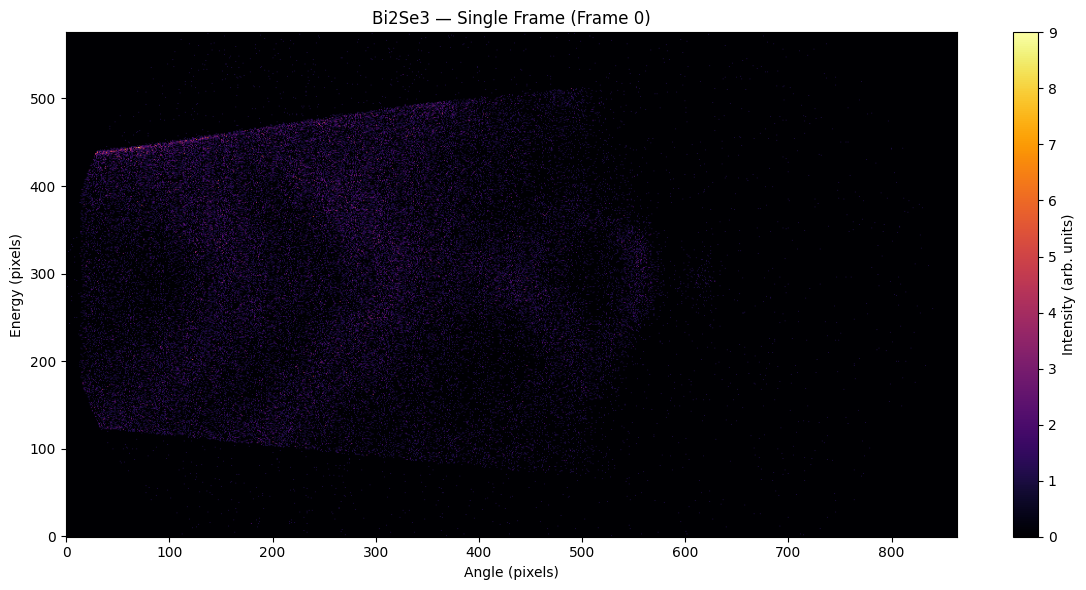

In [17]:
# Extract the 1st frame directly as a 2D image
frame0 = data.squeeze()[4]  # Shape: (576, 864)

plt.figure(figsize=(12, 6 ))
plt.imshow(frame0, aspect="auto", origin="lower")
plt.colorbar(label="Intensity (arb. units)")
plt.xlabel("Angle (pixels)")
plt.ylabel("Energy (pixels)")
plt.title("Bi2Se3 — Single Frame (Frame 0)")
plt.show()

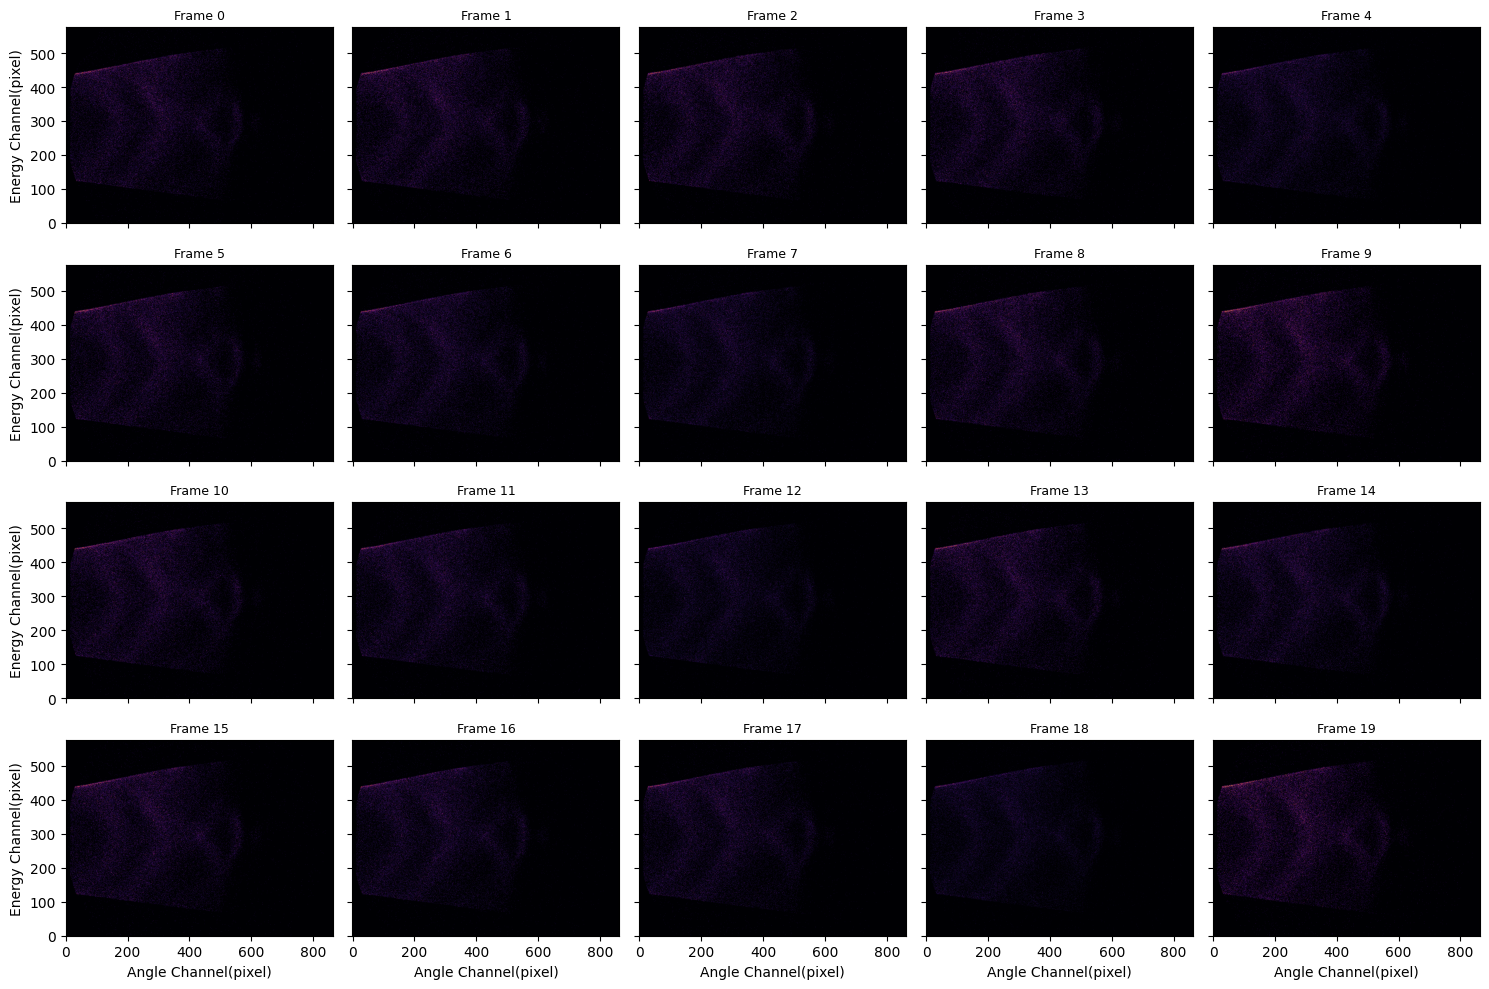

In [18]:
fig, axes = plt.subplots(4, 5, figsize=(15, 10), sharex=True, sharey=True)
for i, ax in enumerate(axes.flat):
    ax.imshow(data.squeeze()[i], aspect="auto", origin="lower")
    ax.set_title(f"Frame {i}", fontsize=9)
    if i >= 15:
        ax.set_xlabel("Angle Channel(pixel)")  # Bottom row only
    if i % 5 == 0:
        ax.set_ylabel("Energy Channel(pixel)")  # Leftmost column only
plt.show()

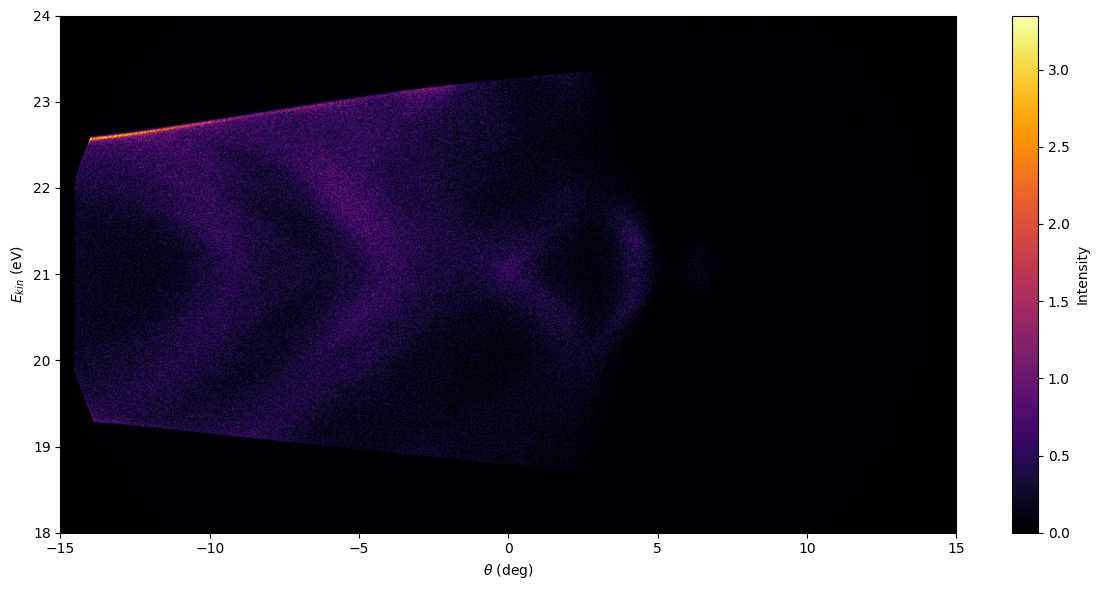

In [20]:
ext = [-15, 15, 18, 24]  # [Angle_min, Angle_max, E_min, E_max]

plt.figure(figsize=(12, 6))
plt.imshow(img2d, extent=ext, aspect="auto", origin="lower")
plt.colorbar(label="Intensity")
plt.xlabel(r"$\theta$ (deg)")
plt.ylabel(r"$E_{kin}$ (eV)")
plt.show()

In [27]:
img2d #uncleaned

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [32]:
from scipy.ndimage import median_filter

In [33]:
#Dark background subtraction (baseline from unexposed corner pixels)
bg = np.median(img2d[:20, :20])
img_clean = np.maximum(img2d - bg, 0)

#2D Median filter (removes dead/hot pixels and cosmic spikes)
img_clean = median_filter(img_clean, size=3)
img_clean #cleaned

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

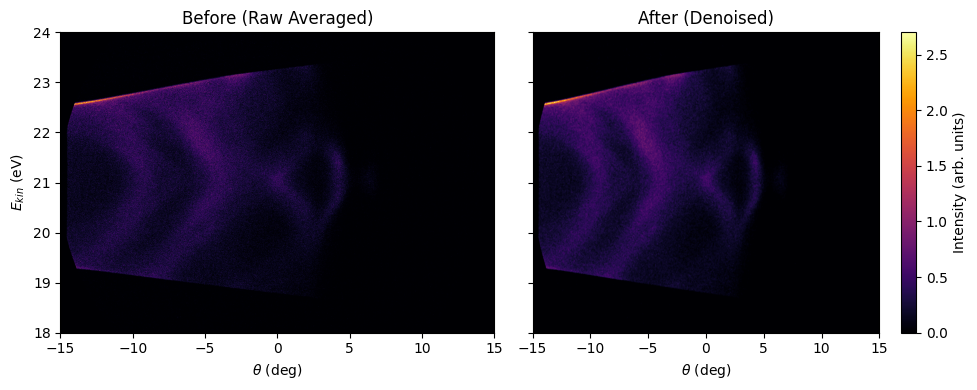

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

ax1.imshow(img2d, extent=ext, aspect="auto", origin="lower")
ax1.set_title("Before (Raw Averaged)")
ax1.set_xlabel(r"$\theta$ (deg)")
ax1.set_ylabel(r"$E_{kin}$ (eV)")

im = ax2.imshow(img_clean, extent=ext, aspect="auto", origin="lower")
ax2.set_title("After (Denoised)")
ax2.set_xlabel(r"$\theta$ (deg)")

fig.colorbar(im, ax=ax2, label="Intensity (arb. units)")  # Attached cleanly to ax2
plt.show()

Physics in your image: Notice how clearly the Dirac cone of 
Bi
2
Se
3
Bi 
2
​
 Se 
3
​
  is centered aroud
θ≈0 
∘
  and 
E 
kin
​
 ≈21.1 eV, with the Fermi level visible around
E_kin
​
 ≈22.6−23.0 eV!

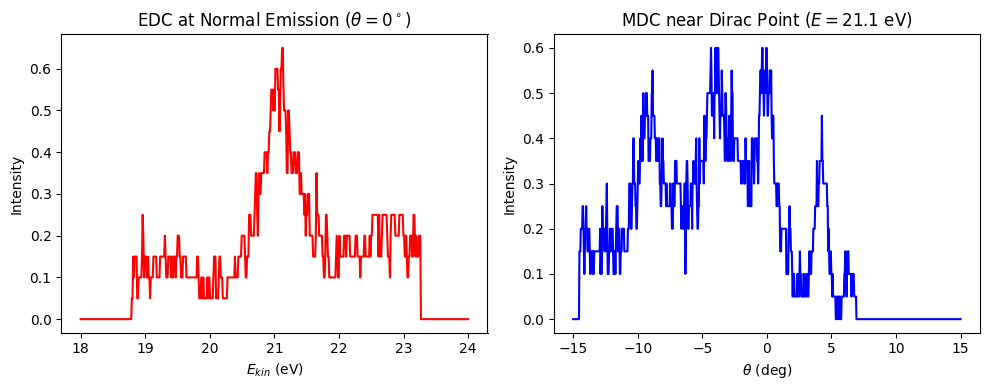

In [48]:
#1D Cuts extraction (Energy Distribution Curves - EDC & Momentum Distribution Curves - MDC)
th_axis = np.linspace(ext[0], ext[1], img_clean.shape[1])  # 864 angle values

# 2. Extract 1D slices: EDC at normal emission (θ ≈ 0°), MDC at Dirac energy (E ≈ 21.1 eV)
edc = img_clean[:, np.argmin(np.abs(th_axis - 0.0))]
mdc = img_clean[np.argmin(np.abs(E_axis - 21.1)), :]

# 3. Plot 1D Cuts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(E_axis, edc, "r-", lw=1.5)
ax1.set(xlabel=r"$E_{kin}$ (eV)",ylabel="Intensity",title=r"EDC at Normal Emission ($\theta=0^\circ$)")

ax2.plot(th_axis, mdc, "b-", lw=1.5)
ax2.set(xlabel=r"$\theta$ (deg)",ylabel="Intensity",title=r"MDC near Dirac Point ($E=21.1$ eV)")
plt.show()

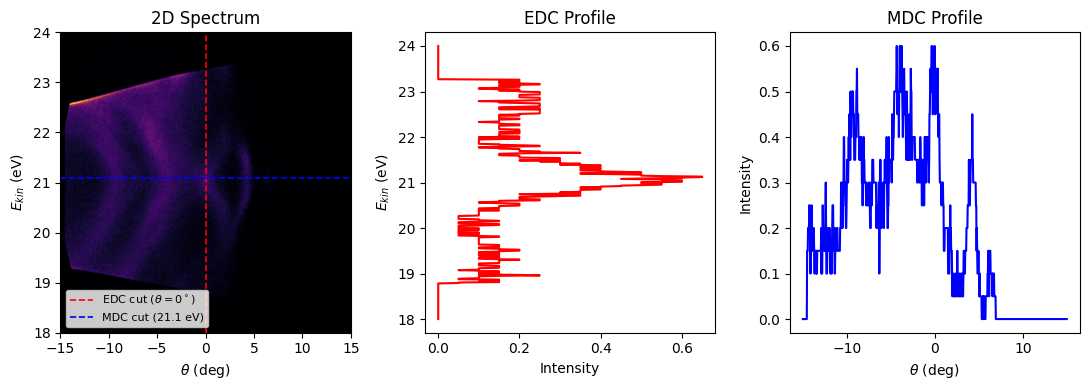

In [42]:
#1D Cuts extraction (Energy Distribution Curves - EDC & Momentum Distribution Curves - MDC).
#1. Choose cut positions: Angle = 0 deg, Energy = 21.1 eV
th_cut, E_cut = 0.0, 21.1
i_E = np.argmin(np.abs(E_axis - E_cut))
j_th = np.argmin(np.abs(th_axis - th_cut))

# 2. Plot 2D map with cut lines + 1D profiles side-by-side
fig = plt.figure(figsize=(11, 4))
ax1 = plt.subplot(131)
ax1.imshow(img_clean, extent=ext, aspect="auto", origin="lower")
ax1.axvline(th_cut, color="r", ls="--", lw=1.2, label=r"EDC cut ($\theta=0^\circ$)")
ax1.axhline(E_cut, color="b", ls="--", lw=1.2, label=f"MDC cut ({E_cut} eV)")
ax1.set(xlabel=r"$\theta$ (deg)", ylabel=r"$E_{kin}$ (eV)", title="2D Spectrum")
ax1.legend(loc="lower left", fontsize=8)

ax2 = plt.subplot(132)
ax2.plot(img_clean[:, j_th], E_axis, "r-", lw=1.5)
ax2.set(xlabel="Intensity", ylabel=r"$E_{kin}$ (eV)", title="EDC Profile")

ax3 = plt.subplot(133)
ax3.plot(th_axis, img_clean[i_E, :], "b-", lw=1.5)
ax3.set(xlabel=r"$\theta$ (deg)", ylabel="Intensity", title="MDC Profile")
plt.show()

Fermi Edge (
E
F
E 
F
​
 ) calibration & non-linear Fermi-Dirac fitting.

C:\Users\mdram\AppData\Local\Temp\ipykernel_8596\2287482605.py:5: RuntimeWarning: overflow encountered in exp
  return I0 / (np.exp((E - EF) / np.maximum(w, 1e-4)) + 1) + bg
C:\Users\mdram\AppData\Local\Temp\ipykernel_8596\2287482605.py:10: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(fermi_step,E_axis[mask],edc[mask],p0=[22.8, 0.05, edc[mask].max(), edc[mask].min()],)


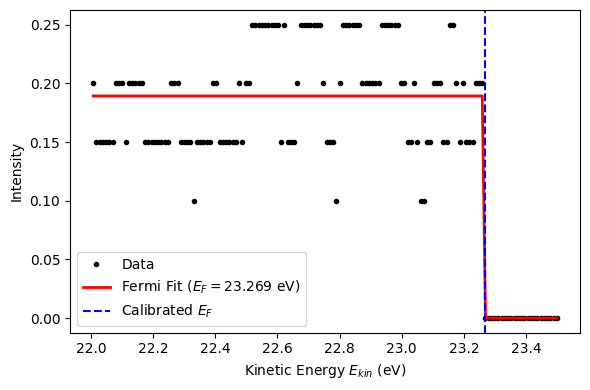

In [47]:
from scipy.optimize import curve_fit

# 1. Fermi-Dirac step function model
def fermi_step(E, EF, w, I0, bg):
    return I0 / (np.exp((E - EF) / np.maximum(w, 1e-4)) + 1) + bg


# 2. Select energy region around the high-energy cutoff (~22.0 to 23.5 eV)
mask = (E_axis >= 22.0) & (E_axis <= 23.5)
popt, _ = curve_fit(fermi_step,E_axis[mask],edc[mask],p0=[22.8, 0.05, edc[mask].max(), edc[mask].min()],)
EF_val = popt[0]

# 3. Plot the Fermi Edge Fit
plt.figure(figsize=(6, 4))
plt.plot(E_axis[mask], edc[mask], "k.", label="Data")
plt.plot(E_axis[mask],fermi_step(E_axis[mask], *popt),"r-",lw=2,label=f"Fermi Fit ($E_F={EF_val:.3f}$ eV)",)
plt.axvline(EF_val, color="b", ls="--", label=r"Calibrated $E_F$")
plt.xlabel(r"Kinetic Energy $E_{kin}$ (eV)")
plt.ylabel("Intensity")
plt.legend()
plt.show()

Angle-to-Momentum (
k
k-space) Conversion

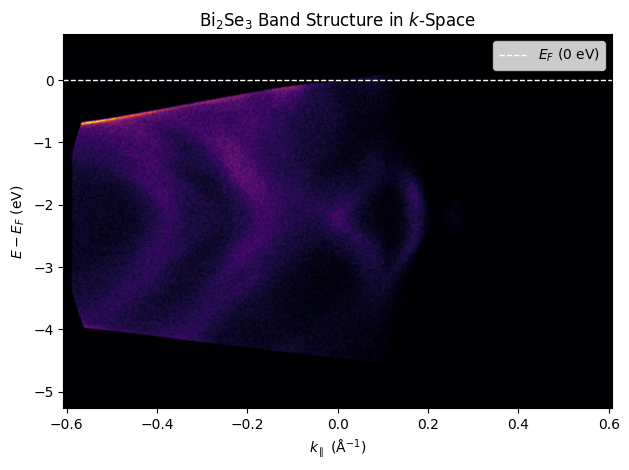

In [50]:
# 1. Convert to Binding Energy (E - E_F) and Crystal Momentum k_|| (1/Å)
E_bind = E_axis - EF_val  # Fermi level at 0 eV
k_par = 0.5123 * np.sqrt(np.mean(E_axis)) * np.sin(np.radians(th_axis))  # k_|| (Å⁻¹)

# 2. Plot calibrated Band Structure E vs k_||
ext_k = [k_par[0], k_par[-1], E_bind[0], E_bind[-1]]
plt.imshow(img_clean, extent=ext_k, aspect="auto", origin="lower")
plt.axhline(0, color="w", ls="--", lw=1, label=r"$E_F$ (0 eV)")
plt.xlabel(r"$k_\parallel$ ($\mathrm{\AA}^{-1}$)")
plt.ylabel(r"$E - E_F$ (eV)")
plt.title(r"$\text{Bi}_2\text{Se}_3$ Band Structure in $k$-Space")
plt.legend(loc="upper right")
plt.show()

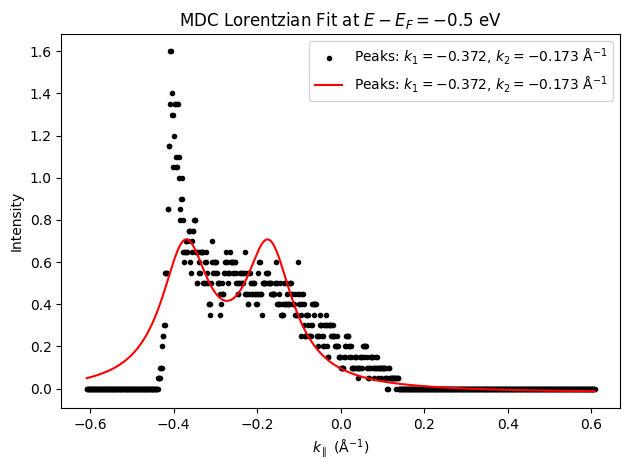

In [51]:
# 1. Double Lorentzian + Background model
def d_lor(k, k1, k2, w, A, bg):
    return (
        A * (w / 2) ** 2 / ((k - k1) ** 2 + (w / 2) ** 2)
        + A * (w / 2) ** 2 / ((k - k2) ** 2 + (w / 2) ** 2)
        + bg
    )


# 2. Extract MDC at E - EF ≈ -0.5 eV and fit
idx = np.argmin(np.abs(E_bind - (-0.5)))
mdc_cut = img_clean[idx, :]
popt_mdc, _ = curve_fit(
    d_lor, k_par, mdc_cut, p0=[-0.1, 0.1, 0.05, mdc_cut.max(), mdc_cut.min()]
)

# 3. Plot Data & Fitted Dirac Cone Branches
plt.plot(
    k_par,
    mdc_cut,
    "k.",
    k_par,
    d_lor(k_par, *popt_mdc),
    "r-",
    label=f"Peaks: $k_1={popt_mdc[0]:.3f}$, $k_2={popt_mdc[1]:.3f}$ $\\mathrm{{\\AA}}^{{-1}}$",
)
plt.title(f"MDC Lorentzian Fit at $E - E_F = -0.5$ eV")
plt.xlabel(r"$k_\parallel$ ($\mathrm{\AA}^{-1}$)")
plt.ylabel("Intensity")
plt.legend()
plt.show()

In [52]:
# 1. Double Lorentzian + Background function
def d_lor(k, k1, k2, w, A, bg):
    return (
        A * (w / 2) ** 2 / ((k - k1) ** 2 + (w / 2) ** 2)
        + A * (w / 2) ** 2 / ((k - k2) ** 2 + (w / 2) ** 2)
        + bg
    )


# 2. Extract MDC at E - EF ≈ -0.5 eV and fit
idx = np.argmin(np.abs(E_bind - (-0.5)))
mdc_cut = img_clean[idx, :]
popt_mdc, _ = curve_fit(
    d_lor, k_par, mdc_cut, p0=[-0.1, 0.1, 0.05, mdc_cut.max(), mdc_cut.min()]
)

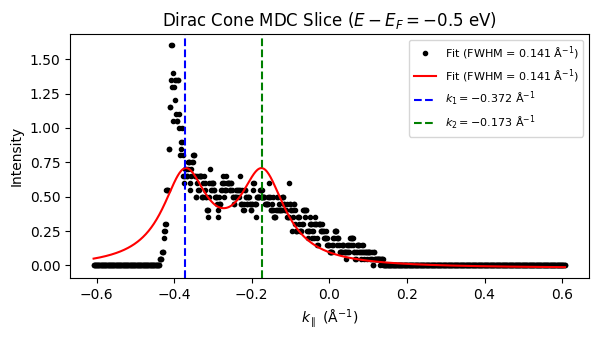

In [53]:
k1, k2, w, A, bg = popt_mdc

plt.figure(figsize=(6, 3.5))
plt.plot(
    k_par,
    mdc_cut,
    "k.",
    k_par,
    d_lor(k_par, *popt_mdc),
    "r-",
    label=f"Fit (FWHM = {w:.3f} $\\mathrm{{\\AA}}^{{-1}}$)",
)
plt.axvline(k1, color="b", ls="--", label=f"$k_1 = {k1:.3f}$ $\\mathrm{{\\AA}}^{{-1}}$")
plt.axvline(k2, color="g", ls="--", label=f"$k_2 = {k2:.3f}$ $\\mathrm{{\\AA}}^{{-1}}$")
plt.xlabel(r"$k_\parallel$ ($\mathrm{\AA}^{-1}$)")
plt.ylabel("Intensity")
plt.title(r"Dirac Cone MDC Slice ($E - E_F = -0.5$ eV)")
plt.legend(fontsize=8)
plt.show()

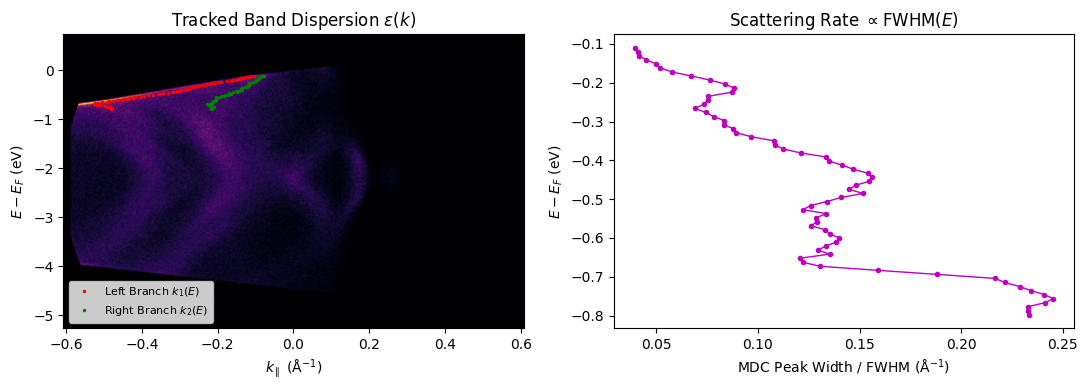

In [54]:
# 1. Select energy range for topological cone (E - EF from -0.8 eV to -0.1 eV)
e_mask = (E_bind >= -0.8) & (E_bind <= -0.1)
E_track = E_bind[e_mask]
k1_pts, k2_pts, fwhm_pts = [], [], []

# 2. Sequential MDC fitting loop
p = popt_mdc  # Initial parameter guess
for idx in np.where(e_mask)[0]:
    try:
        p, _ = curve_fit(d_lor, k_par, img_clean[idx, :], p0=p, maxfev=800)
        k1_pts.append(p[0])
        k2_pts.append(p[1])
        fwhm_pts.append(abs(p[2]))
    except:
        k1_pts.append(np.nan)
        k2_pts.append(np.nan)
        fwhm_pts.append(np.nan)

# 3. Overlay tracked dispersion onto 2D Spectrum & Plot FWHM
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.imshow(img_clean, extent=ext_k, aspect="auto", origin="lower")
ax1.plot(k1_pts, E_track, "r.", ms=3, label=r"Left Branch $k_1(E)$")
ax1.plot(k2_pts, E_track, "g.", ms=3, label=r"Right Branch $k_2(E)$")
ax1.set(
    xlabel=r"$k_\parallel$ ($\mathrm{\AA}^{-1}$)",
    ylabel=r"$E - E_F$ (eV)",
    title=r"Tracked Band Dispersion $\epsilon(k)$",
)
ax1.legend(loc="lower left", fontsize=8)

ax2.plot(fwhm_pts, E_track, "m.-", lw=1)
ax2.set(
    xlabel=r"MDC Peak Width / FWHM ($\mathrm{\AA}^{-1}$)",
    ylabel=r"$E - E_F$ (eV)",
    title=r"Scattering Rate $\propto \text{FWHM}(E)$",
)
plt.show()

Topological Band Parameters Extraction:
Determining Dirac Point position (
E
D
E 
D
​
 ), Fermi velocity (
v
F
v 
F
​
 ), and Dirac cone slope for 
Bi
2
Se
3
Bi 
2
​
 Se 
3
​
 .

In [58]:
# 1. Convert to arrays and filter valid (non-NaN) right branch points
k2 = np.array(k2_pts)
valid = ~np.isnan(k2) & (k2 > 0)

# 2. Linear fit: E = slope * k + ED
slope, ED = np.polyfit(k2[valid], E_track[valid], 1)
vF = slope * 1.51926e5  # Convert eV·Å → m/s

print(f"Dirac Point ED = {ED:.3f} eV below EF")
print(f"Fermi Velocity vF = {vF/1e5:.2f} × 10⁵ m/s")

# 3. Overlay on 2D spectrum
k_fit = k2[valid]
plt.imshow(img_clean, extent=ext_k, aspect="auto", origin="lower")
plt.plot(k_fit, np.polyval([slope, ED], k_fit), "r-", lw=2, label=f"$v_F={vF/1e5:.2f}\\times10^5$ m/s")
plt.axhline(ED, color="cyan", ls=":", label=f"$E_D={ED:.2f}$ eV")
plt.xlabel(r"$k_\parallel$ ($\mathrm{\AA}^{-1}$)")
plt.ylabel(r"$E - E_F$ (eV)")
plt.legend(fontsize=8)
plt.show()

TypeError: expected non-empty vector for x

Dirac Point (ED): -2.243 eV
Fermi Velocity (vF): 2.15 × 10⁵ m/s


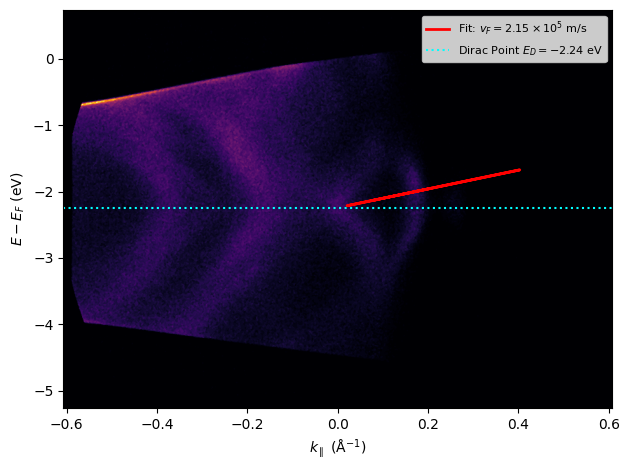

In [59]:
# 1. Direct peak tracking on left (k < 0) and right (k > 0) branches
k_mid = len(k_par) // 2
k_r_pts, E_fit_pts = [], []

# Scan across all binding energies below EF
for i in range(len(E_bind)):
    row = img_clean[i]
    if row.max() > row.mean() * 1.4:  # True signal condition
        k_max_right = k_par[k_mid + np.argmax(row[k_mid:])]
        if k_max_right > 0.02:  # Positive branch peak
            k_r_pts.append(k_max_right)
            E_fit_pts.append(E_bind[i])

# 2. Linear fit for Dirac Cone slope & Dirac Point
k_arr, E_arr = np.array(k_r_pts), np.array(E_fit_pts)
slope, ED = np.polyfit(k_arr, E_arr, deg=1)
vF = slope * 1.51926e5  # eV·Å -> m/s

print(f"Dirac Point (ED): {ED:.3f} eV")
print(f"Fermi Velocity (vF): {vF/1e5:.2f} × 10⁵ m/s")

# 3. Plot overlay on 2D spectrum
plt.imshow(img_clean, extent=ext_k, aspect="auto", origin="lower")
plt.plot(
    k_arr,
    np.polyval([slope, ED], k_arr),
    "r-",
    lw=2,
    label=f"Fit: $v_F={vF/1e5:.2f}\\times 10^5$ m/s",
)
plt.axhline(ED, color="cyan", ls=":", label=f"Dirac Point $E_D={ED:.2f}$ eV")
plt.xlabel(r"$k_\parallel$ ($\mathrm{\AA}^{-1}$)")
plt.ylabel(r"$E - E_F$ (eV)")
plt.legend(fontsize=8)
plt.show()

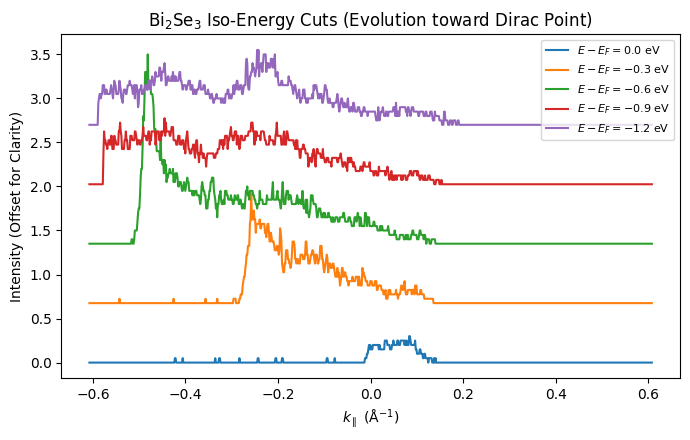

In [60]:
# 1. Select binding energy slices below EF (e.g., 0 eV, -0.3 eV, -0.6 eV, -0.9 eV, -1.2 eV)
energies = [0.0, -0.3, -0.6, -0.9, -1.2]
plt.figure(figsize=(7, 4.5))

# 2. Plot waterfall/stacked constant energy cuts
for offset, E_val in enumerate(energies):
    i = np.argmin(np.abs(E_bind - E_val))
    mdc_slice = img_clean[i, :]
    plt.plot(
        k_par,
        mdc_slice + offset * (img_clean.max() * 0.25),
        label=f"$E - E_F = {E_val:.1f}$ eV",
    )

plt.xlabel(r"$k_\parallel$ ($\mathrm{\AA}^{-1}$)")
plt.ylabel("Intensity (Offset for Clarity)")
plt.title(
    r"$\text{Bi}_2\text{Se}_3$ Iso-Energy Cuts (Evolution toward Dirac Point)"
)
plt.legend(loc="upper right", fontsize=8)
plt.show()

In [ ]:
12
